In [1]:
import seaborn as sns
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


from scipy.stats import multivariate_normal as mvn
from sklearn.mixture import GaussianMixture

In [2]:
def calculate_posterior(px, pi):
    """
    
    """
    weighted_px = px * pi  # broadcasting pi over rows of px

    # Denominator: sum over components for each data point i
    denom = weighted_px.sum(axis=1)  # shape (n,)

    # Posterior (responsibilities), shape (n, K)
    gamma = weighted_px / denom[:, np.newaxis]
    return gamma

In [73]:
# Load the iris dataset
iris = sns.load_dataset('iris')

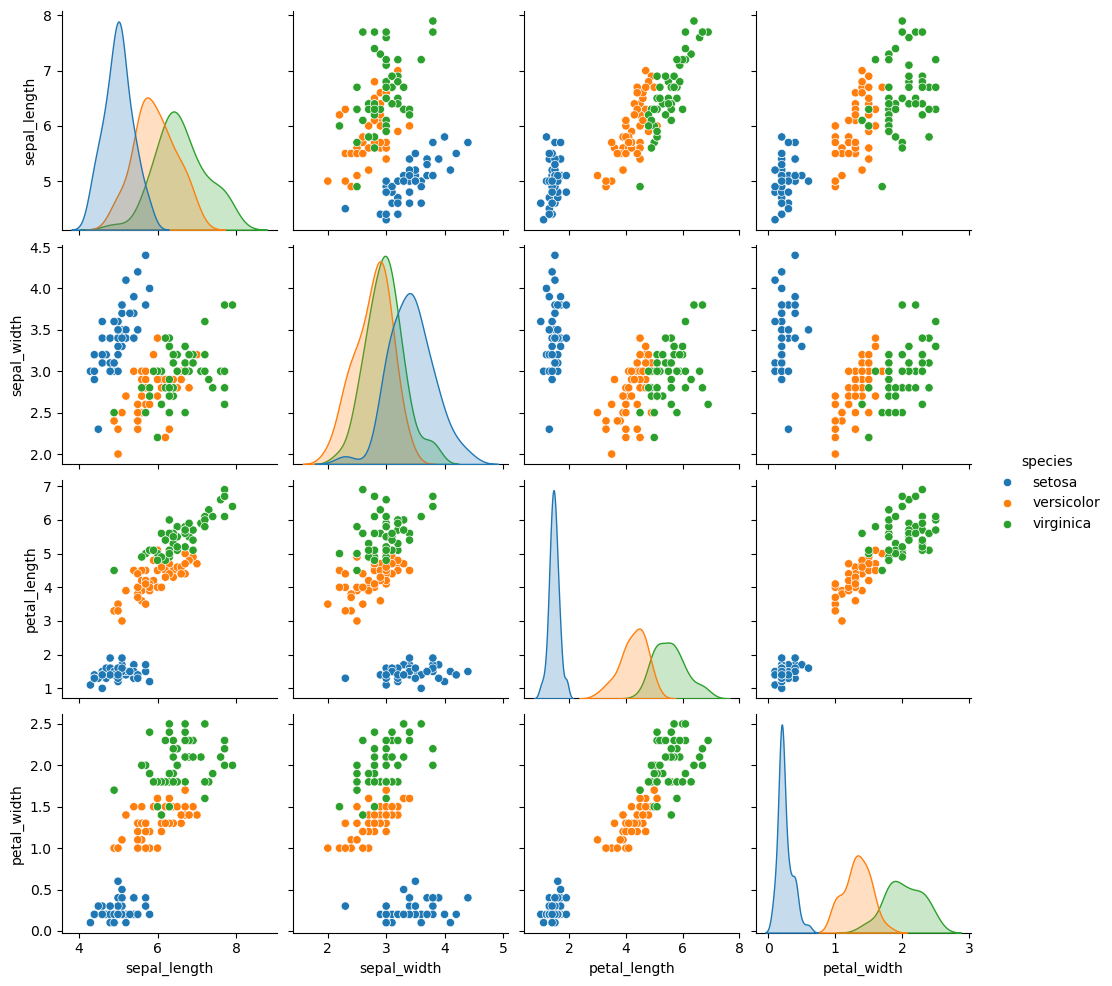

In [74]:
sns.pairplot(iris, hue='species')

/opt/miniconda3/envs/ds/lib/python3.11/site-packages/seaborn/distributions.py:1128: UserWarning: cmap parameter ignored when using hue mapping.
  warnings.warn(msg, UserWarning)


<Axes: xlabel='sepal_length', ylabel='sepal_width'>

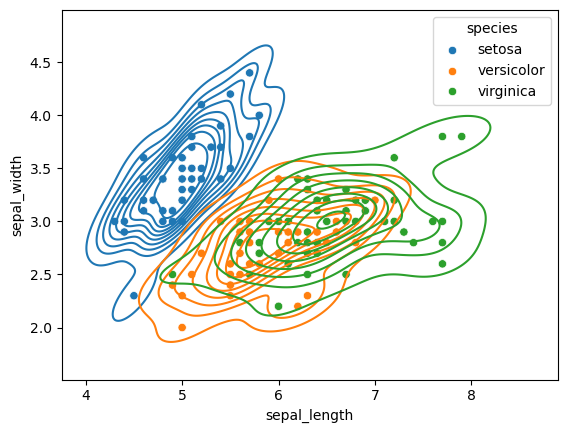

In [ ]:



sns.kdeplot(data=iris,
            x='sepal_length',
            y='sepal_width',
            hue='species',
            thresh=0.05,
            levels=10,cmap='mako')
sns.scatterplot(data=iris, x='sepal_length', y='sepal_width',hue='species',)

/opt/miniconda3/envs/ds/lib/python3.11/site-packages/seaborn/distributions.py:1128: UserWarning: cmap parameter ignored when using hue mapping.
  warnings.warn(msg, UserWarning)


<Axes: xlabel='sepal_length', ylabel='petal_length'>

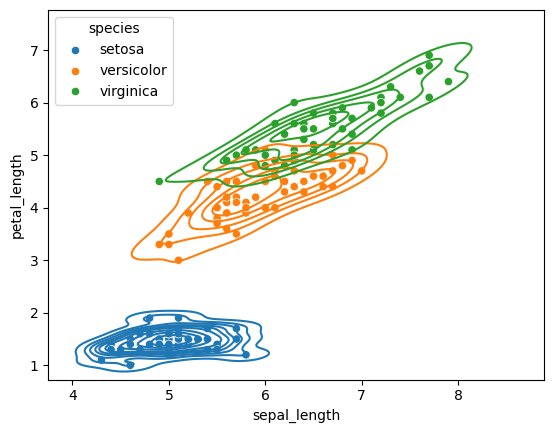

In [4]:
sns.kdeplot(data=iris,
            x='sepal_length',
            y='petal_length',
            hue='species',
            thresh=0.05,
            levels=10,cmap='mako')
sns.scatterplot(data=iris, x='sepal_length', y='petal_length',hue='species',)

In [5]:
from sklearn.mixture import GaussianMixture

In [6]:
# For multivariate data (e.g., eruptions and waiting)
gmm = GaussianMixture(n_components=3, random_state=0)
gmm.fit(iris.iloc[:,:4])

GaussianMixture(n_components=3, random_state=0)

In [7]:
# Accessing the parameters
means = gmm.means_
covariances = gmm.covariances_
weights = gmm.weights_

print("Means:\n", means)
print("\nCovariances:\n", covariances)
print("\nMixing Proportions:\n", weights)

Means:
 [[5.9170732  2.77804839 4.20540364 1.29848217]
 [5.006      3.428      1.462      0.246     ]
 [6.54639415 2.94946365 5.48364578 1.98726565]]

Covariances:
 [[[0.2755171  0.09662295 0.18547072 0.05478901]
  [0.09662295 0.09255152 0.09103431 0.04299899]
  [0.18547072 0.09103431 0.20235849 0.06171383]
  [0.05478901 0.04299899 0.06171383 0.03233775]]

 [[0.121765   0.097232   0.016028   0.010124  ]
  [0.097232   0.140817   0.011464   0.009112  ]
  [0.016028   0.011464   0.029557   0.005948  ]
  [0.010124   0.009112   0.005948   0.010885  ]]

 [[0.38744093 0.09223276 0.30244302 0.06087397]
  [0.09223276 0.11040914 0.08385112 0.05574334]
  [0.30244302 0.08385112 0.32589574 0.07276776]
  [0.06087397 0.05574334 0.07276776 0.08484505]]]

Mixing Proportions:
 [0.30127092 0.33333333 0.36539575]


In [8]:
iris.groupby('species').mean()

,sepal_length,sepal_width,petal_length,petal_width
species,,,,
setosa,5.006,3.428,1.462,0.246
versicolor,5.936,2.770,4.260,1.326
virginica,6.588,2.974,5.552,2.026


In [9]:
### Initialize


# Extract the 2D data (eruptions and waiting).
X = iris.iloc[:,:4].to_numpy()

mu1_hat = np.array(list(iris.iloc[:,:4].sample(1).iloc[0]))
mu2_hat = np.array(list(iris.iloc[:,:4].sample(1).iloc[0]))
mu3_hat = np.array(list(iris.iloc[:,:4].sample(1).iloc[0]))

# Initialize two covariance matrices as identity for simplicity.
Sigma1_hat = np.eye(X.shape[1])
Sigma2_hat = np.eye(X.shape[1])
Sigma3_hat = np.eye(X.shape[1])

# Mixing proportions (still scalars).
pi1_hat = 1/3
pi2_hat = 1/3
pi3_hat = 1/3

In [10]:
epoch_log_likelihood = {}

for i in range(50):

    px_class1 = [mvn(mean=mu1_hat, cov=Sigma1_hat).pdf(xi) for xi in X]
    px_class2 = [mvn(mean=mu2_hat, cov=Sigma2_hat).pdf(xi) for xi in X]
    px_class3 = [mvn(mean=mu3_hat, cov=Sigma3_hat).pdf(xi) for xi in X]

    px_class1 = np.array(px_class1)  # convert list to array
    px_class2 = np.array(px_class2)
    px_class3 = np.array(px_class3)   

    log_likelihood = np.sum(
    np.log( ( 
                pi1_hat * px_class1) + (pi2_hat * px_class2) + (pi3_hat * px_class3) 
            )
        )

    epoch_log_likelihood[i] = log_likelihood

    px = np.column_stack([px_class1, px_class2, px_class3])
    # Now px.shape == (n, 3)

    pi = np.array([pi1_hat, pi2_hat, pi3_hat])   # shape (3,)

    posteriors = calculate_posterior(px, pi)

    ## Maximization step

    ### Cluster 1
    posteriors_class1 = posteriors[:,0]

    # 1) Mean
    N1 = posteriors_class1.sum()
    mu1_hat = (X * posteriors_class1[:, None]).sum(axis=0) / N1

    # 2) Covariance
    diff1 = X - mu1_hat
    Sigma1_hat = (posteriors_class1[:, None] * diff1).T @ diff1 / N1
    ############################################################################################################

    ### Cluster 2
    posteriors_class2 = posteriors[:,1]

    # 1) Mean
    N2 = posteriors_class2.sum()
    mu2_hat = (X * posteriors_class2[:, None]).sum(axis=0) / N2

    # 2) Covariance
    diff2 = X - mu2_hat
    Sigma2_hat = (posteriors_class2[:, None] * diff2).T @ diff2 / N2
    ############################################################################################################

    ### Cluster 3
    posteriors_class3 = posteriors[:,2]

    # 1) Mean
    N3 = posteriors_class3.sum()
    mu3_hat = (X * posteriors_class3[:, None]).sum(axis=0) / N3

    # 2) Covariance
    diff3 = X - mu3_hat
    Sigma3_hat = (posteriors_class3[:, None] * diff3).T @ diff3 / N3
    ############################################################################################################

    pi1_hat = sum(posteriors_class1) / len(X)
    pi2_hat = sum(posteriors_class2) / len(X)
    pi3_hat = sum(posteriors_class3) / len(X)


In [11]:
print("mu1_hat =", mu1_hat)
print("mu2_hat =", mu2_hat)
print("mu3_hat =", mu3_hat)

mu1_hat = [5.006 3.428 1.462 0.246]
mu2_hat = [5.91496959 2.77784365 4.20155323 1.29696685]
mu3_hat = [6.54454865 2.94866115 5.47955343 1.98460495]


In [12]:
gmm.means_

array([[5.9170732 , 2.77804839, 4.20540364, 1.29848217],
       [5.006     , 3.428     , 1.462     , 0.246     ],
       [6.54639415, 2.94946365, 5.48364578, 1.98726565]])

In [13]:
print("Sigma1_hat =", Sigma1_hat)
print("Sigma2_hat =", Sigma2_hat)
print("Sigma3_hat =", Sigma3_hat)

Sigma1_hat = [[0.121764 0.097232 0.016028 0.010124]
 [0.097232 0.140816 0.011464 0.009112]
 [0.016028 0.011464 0.029556 0.005948]
 [0.010124 0.009112 0.005948 0.010884]]
Sigma2_hat = [[0.27531878 0.09694138 0.18466239 0.05439074]
 [0.09694138 0.09264604 0.09114317 0.04299735]
 [0.18466239 0.09114317 0.20063041 0.06097847]
 [0.05439074 0.04299735 0.06097847 0.03199695]]
Sigma3_hat = [[0.38704429 0.09220792 0.30281173 0.06165105]
 [0.09220792 0.1103377  0.08428758 0.0560115 ]
 [0.30281173 0.08428758 0.32779736 0.07453004]
 [0.06165105 0.0560115  0.07453004 0.08579773]]


In [14]:
gmm.covariances_

array([[[0.2755171 , 0.09662295, 0.18547072, 0.05478901],
        [0.09662295, 0.09255152, 0.09103431, 0.04299899],
        [0.18547072, 0.09103431, 0.20235849, 0.06171383],
        [0.05478901, 0.04299899, 0.06171383, 0.03233775]],

       [[0.121765  , 0.097232  , 0.016028  , 0.010124  ],
        [0.097232  , 0.140817  , 0.011464  , 0.009112  ],
        [0.016028  , 0.011464  , 0.029557  , 0.005948  ],
        [0.010124  , 0.009112  , 0.005948  , 0.010885  ]],

       [[0.38744093, 0.09223276, 0.30244302, 0.06087397],
        [0.09223276, 0.11040914, 0.08385112, 0.05574334],
        [0.30244302, 0.08385112, 0.32589574, 0.07276776],
        [0.06087397, 0.05574334, 0.07276776, 0.08484505]]])

In [15]:
print("pi1_hat =", pi1_hat)
print("pi2_hat =", pi2_hat)
print("pi3_hat =", pi3_hat)

pi1_hat = 0.3333333333333333
pi2_hat = 0.2991931877208459
pi3_hat = 0.36747347894582083


In [20]:
gmm.weights_

array([0.30127092, 0.33333333, 0.36539575])

### Assign probability to each entry

In [23]:
X[0]

array([5.1, 3.5, 1.4, 0.2])

In [34]:
pxi_class1 = mvn(mean=mu1_hat, cov=Sigma1_hat).pdf(X[0]) 
pxi_class2 = mvn(mean=mu2_hat, cov=Sigma2_hat).pdf(X[0]) 
pxi_class3 = mvn(mean=mu3_hat, cov=Sigma3_hat).pdf(X[0]) 

In [35]:
prob_from_class1 = pi1_hat * pxi_class1
prob_from_class2 = pi2_hat * pxi_class2
prob_from_class3 = pi3_hat * pxi_class3

In [36]:
total = prob_from_class1 + prob_from_class2 + prob_from_class3

post_Xi_class1 = prob_from_class1 / total
post_Xi_class2 = prob_from_class2 / total
post_Xi_class3 = prob_from_class3 / total

In [38]:
np.sum([post_Xi_class1, post_Xi_class2, post_Xi_class3])

1.0

__or__

In [ ]:
pxi_class1 = mvn(mean=mu1_hat, cov=Sigma1_hat).pdf(X[0]) 
pxi_class2 = mvn(mean=mu2_hat, cov=Sigma2_hat).pdf(X[0]) 
pxi_class3 = mvn(mean=mu3_hat, cov=Sigma3_hat).pdf(X[0]) 

In [42]:
px = np.column_stack([pxi_class1, pxi_class2, pxi_class3])
pi = np.array([pi1_hat, pi2_hat, pi3_hat])   

posteriors = calculate_posterior(px, pi)
posteriors # Probability that the first data point belongs to each of the three clusters

array([[1.00000000e+00, 8.87649931e-45, 2.46041862e-34]])

In [58]:
### For all data points

px_class1 = [mvn(mean=mu1_hat, cov=Sigma1_hat).pdf(x) for x in X] 
px_class2 = [mvn(mean=mu2_hat, cov=Sigma2_hat).pdf(x) for x in X] 
px_class3 = [mvn(mean=mu3_hat, cov=Sigma3_hat).pdf(x) for x in X] 

px = np.column_stack([px_class1, px_class2, px_class3])
pi = np.array([pi1_hat, pi2_hat, pi3_hat])   

posteriors = calculate_posterior(px, pi)
posteriors_df = pd.DataFrame(posteriors, columns=['Cluster 1', 'Cluster 2', 'Cluster 3'])

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 2, 1, 2, 1, 2, 1, 1, 1, 1, 2, 1, 1, 1, 1, 1, 2, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2])

In [66]:
per_point_data = pd.DataFrame(X).join(posteriors_df)
per_point_data['cluster_membership'] = np.argmax(posteriors,1)
per_point_data


,0,1,2,3,Cluster 1,Cluster 2,Cluster 3,cluster_membership
0,5.1,3.5,1.4,0.2,1.000000e+00,8.876499e-45,2.460419e-34,0
1,4.9,3.0,1.4,0.2,1.000000e+00,1.645354e-31,8.536458e-28,0
2,4.7,3.2,1.3,0.2,1.000000e+00,1.345255e-36,1.418615e-29,0
3,4.6,3.1,1.5,0.2,1.000000e+00,2.560965e-32,8.040739e-26,0
4,5.0,3.6,1.4,0.2,1.000000e+00,2.830950e-47,1.023018e-34,0
...,...,...,...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,1.127972e-153,2.751544e-15,1.000000e+00,2
146,6.3,2.5,5.0,1.9,3.394183e-127,2.071647e-09,1.000000e+00,2
147,6.5,3.0,5.2,2.0,1.299149e-136,1.106657e-06,9.999989e-01,2
148,6.2,3.4,5.4,2.3,1.143393e-158,1.252038e-10,1.000000e+00,2


In [75]:
iris.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


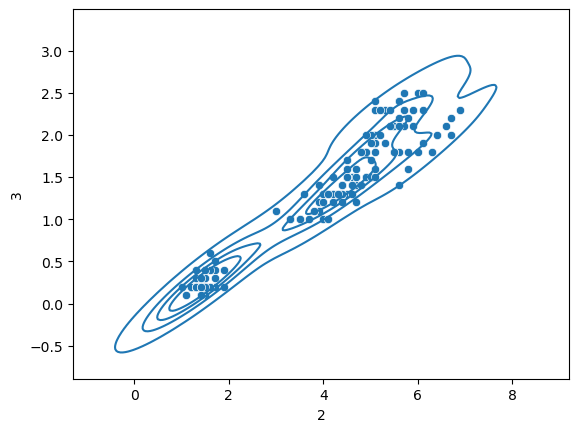

<Axes: xlabel='2', ylabel='3'>

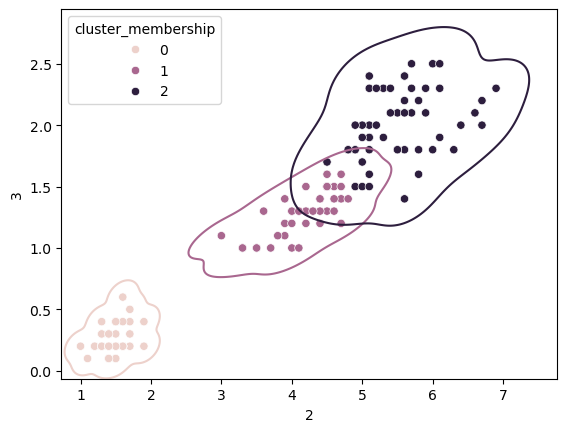

In [134]:
x = 2
y = 3

sns.kdeplot(data=per_point_data,
            x=x,
            y=y,
            #hue='species',
            thresh=0.05,
            levels=5,
            #cmap='mako'
            )
sns.scatterplot(data=per_point_data, x=x, y=y)
plt.show()


sns.kdeplot(data=per_point_data,
            x=x,
            y=y,
            hue='cluster_membership',
            thresh=0.005,
            levels=1,
            #cmap='tab10'
            )
sns.scatterplot(data=per_point_data, x=x, y=y, hue='cluster_membership')

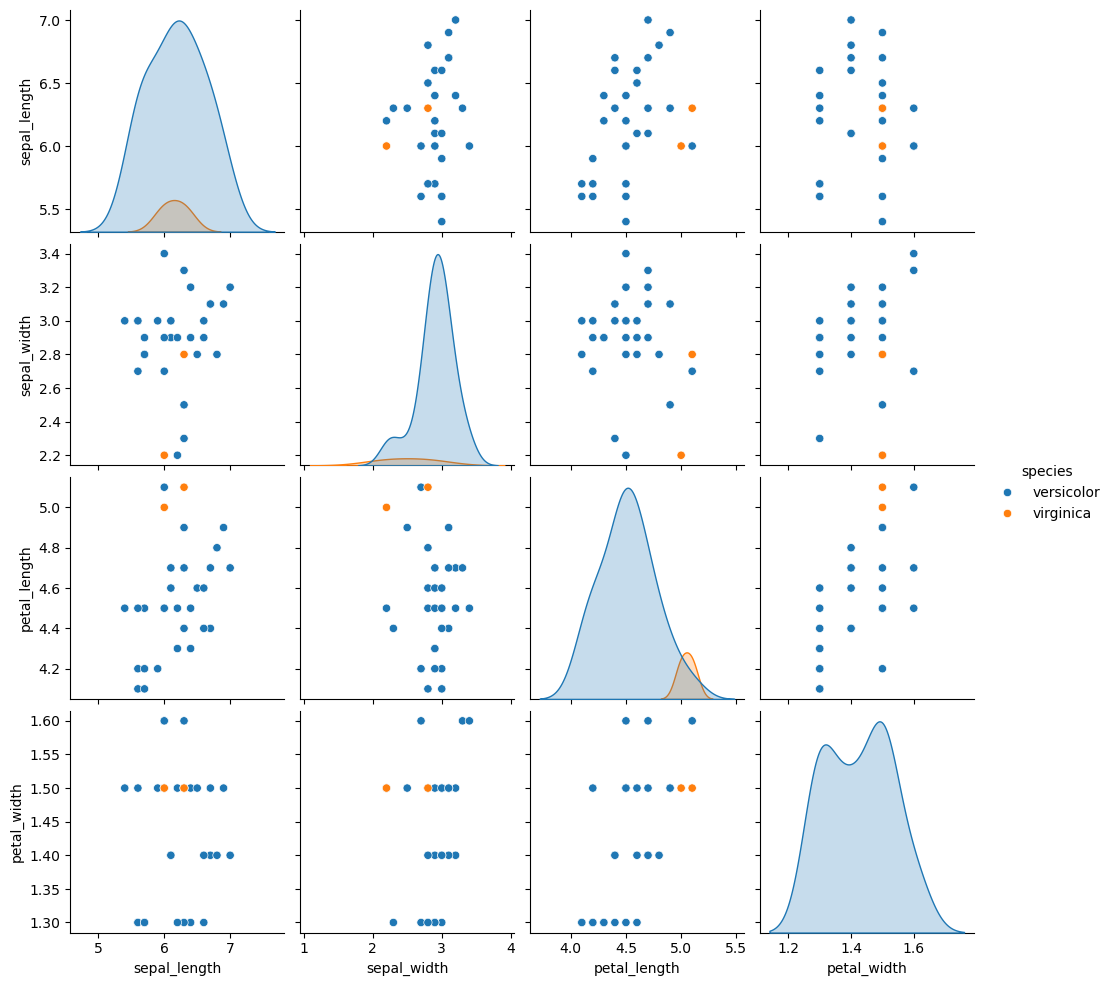

In [93]:
sns.pairplot(iris[(iris['petal_length'] > 4) & (iris['petal_length'] < 5.5) & (iris['petal_width'] > 1.2) & (iris['petal_width'] < 1.7) ], hue='species')

,0,1,2,3,Cluster 1,Cluster 2,Cluster 3,cluster_membership
50,7.0,3.2,4.7,1.4,3.021700e-92,0.999713,0.000287,1
51,6.4,3.2,4.5,1.5,1.147914e-83,0.998593,0.001407,1
52,6.9,3.1,4.9,1.5,1.799163e-104,0.994357,0.005643,1
54,6.5,2.8,4.6,1.5,4.927728e-92,0.969636,0.030364,1
55,5.7,2.8,4.5,1.3,2.956277e-79,0.967993,0.032007,1
56,6.3,3.3,4.7,1.6,8.553638e-94,0.986309,0.013691,1
58,6.6,2.9,4.6,1.3,1.334069e-86,0.998575,0.001425,1
61,5.9,3.0,4.2,1.5,1.636095e-72,0.992619,0.007381,1
63,6.1,2.9,4.7,1.4,1.014711e-90,0.966465,0.033535,1
65,6.7,3.1,4.4,1.4,3.041898e-79,0.999872,0.000128,1


In [124]:
cmap_membership = {1:'tab:blue', 2:'tab:orange', 3:'tab:green'}

In [130]:
per_point_data[(per_point_data[2] > 4) & (per_point_data[2] < 5.5) & (per_point_data[3] > 1.2) & (per_point_data[3] < 1.7) ]

,0,1,2,3,Cluster 1,Cluster 2,Cluster 3,cluster_membership
50,7.0,3.2,4.7,1.4,3.021700e-92,0.999713,0.000287,1
51,6.4,3.2,4.5,1.5,1.147914e-83,0.998593,0.001407,1
52,6.9,3.1,4.9,1.5,1.799163e-104,0.994357,0.005643,1
54,6.5,2.8,4.6,1.5,4.927728e-92,0.969636,0.030364,1
55,5.7,2.8,4.5,1.3,2.956277e-79,0.967993,0.032007,1
56,6.3,3.3,4.7,1.6,8.553638e-94,0.986309,0.013691,1
58,6.6,2.9,4.6,1.3,1.334069e-86,0.998575,0.001425,1
61,5.9,3.0,4.2,1.5,1.636095e-72,0.992619,0.007381,1
63,6.1,2.9,4.7,1.4,1.014711e-90,0.966465,0.033535,1
65,6.7,3.1,4.4,1.4,3.041898e-79,0.999872,0.000128,1


<Axes: xlabel='2', ylabel='3'>

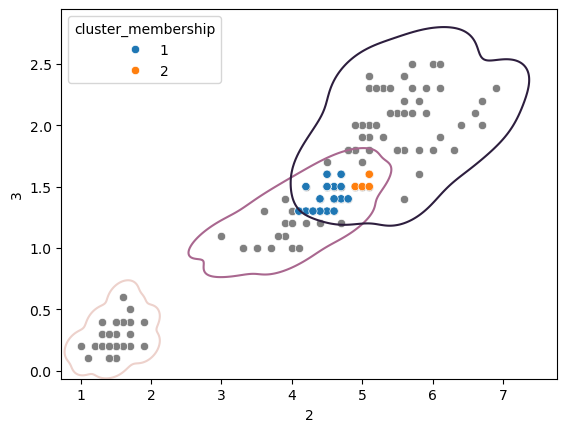

In [125]:
sns.kdeplot(data=per_point_data,
            x=x,
            y=y,
            hue='cluster_membership',
            thresh=0.005,
            levels=1,
            #cmap='mako'
            )
sns.scatterplot(data=per_point_data, x=x, y=y, color='gray')
sns.scatterplot(data=per_point_data[(per_point_data[2] > 4) & (per_point_data[2] < 5.5) & (per_point_data[3] > 1.2) & (per_point_data[3] < 1.7) ],
                x=x, y=y, hue='cluster_membership',palette=cmap_membership)



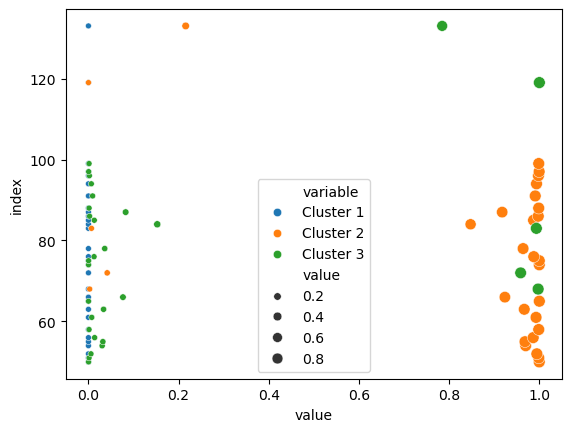

In [120]:
fuzzymembership = per_point_data[(per_point_data[2] > 4) & (per_point_data[2] < 5.5) & (per_point_data[3] > 1.2) & (per_point_data[3] < 1.7) ]
fuzzymembership_melt = fuzzymembership[['Cluster 1', 'Cluster 2', 'Cluster 3','cluster_membership']].reset_index().melt(id_vars=['index','cluster_membership'])

sns.scatterplot(data=fuzzymembership_melt, x='value', y='index', hue='variable', palette='tab10', size='value')
plt.show()

In [128]:
cmap_membership = {'Cluster 1':'tab:blue', 'Cluster 2':'tab:orange', 'Cluster 3':'tab:green'}

<Axes: xlabel='index', ylabel='value'>

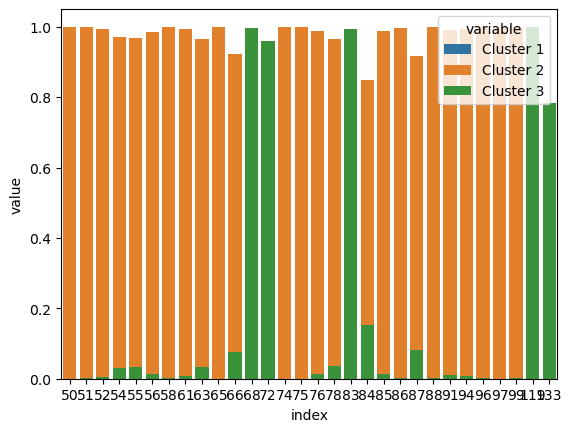

In [129]:
sns.barplot(data=fuzzymembership_melt, x='index', y='value', hue='variable', palette=cmap_membership, dodge=False)

In [ ]:
sns.kdeplot(data=per_point_data,
            x=x,
            y=y,
            hue='cluster_membership',
            thresh=0.005,
            levels=1,
            #cmap='mako'
            )
sns.scatterplot(data=per_point_data, x=x, y=y, color='gray')
sns.scatterplot(data=per_point_data[(per_point_data[2] > 4) & (per_point_data[2] < 5.5) & (per_point_data[3] > 1.2) & (per_point_data[3] < 1.7) ],
                x=x, y=y, hue='cluster_membership',palette='tab10')

